In [45]:
import os
import sys
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines  
from scipy.stats import gaussian_kde

PROJECT_PATH = os.path.abspath(os.path.join("..", ".."))
PIPELINE_PATH = os.path.join(PROJECT_PATH, "pipeline")
DATA_DIRECTORY = os.path.join(PROJECT_PATH, "data")

unflagged_data = False

if PIPELINE_PATH not in sys.path:
    sys.path.append(PIPELINE_PATH)

from utils.paths import DESPIKED_DATA_DIRECTORY
from utils.config_files import load_json_config
from utils.import_data import import_acropolis_site_data
from config.sites_deloyment_times import deployment_times

assert(os.path.exists(DESPIKED_DATA_DIRECTORY))

# load files
config = load_json_config("config.json")

In [41]:
# import all sites with column "site" added
df_sites = []

for site in config["icos_cities_portal"]["site_names"]:

    df_site = import_acropolis_site_data(target_directory=DESPIKED_DATA_DIRECTORY,
                                            deployment_times=deployment_times,
                                            site_name=site) \
            .filter(pl.col("Flag") == "U") \
            .select(["datetime", "gmp343_corrected"]) \
            .with_columns(site = pl.lit(site)) \
            .with_columns(
            pl.col("datetime")
            .dt.convert_time_zone("Europe/Berlin")
            .alias("datetime_local")) \
            .group_by_dynamic("datetime_local", every="1h") \
            .agg(pl.mean("gmp343_corrected").alias("gmp343_corrected"))

    df_sites.append(df_site)
    
df = pl.concat(df_sites).filter(pl.col("gmp343_corrected") < 1000)

In [42]:
x = df["gmp343_corrected"].to_numpy()

# distribution
print(np.percentile(x, [2.5 , 97.5]))

[418.17880021 527.3118625 ]


In [43]:
def freedman_diaconis_bins(x: np.ndarray) -> int:
    """Robust bin count based on the Freedman-Diaconis rule."""
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    n = x.size
    if n < 2:
        return 10
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr == 0:
        return int(np.sqrt(n))
    bw = 2 * iqr * n ** (-1/3)
    if bw <= 0:
        return int(np.sqrt(n))
    bins = int(np.ceil((x.max() - x.min()) / bw))
    return max(bins, 10)

bins = freedman_diaconis_bins(x)
bins

658

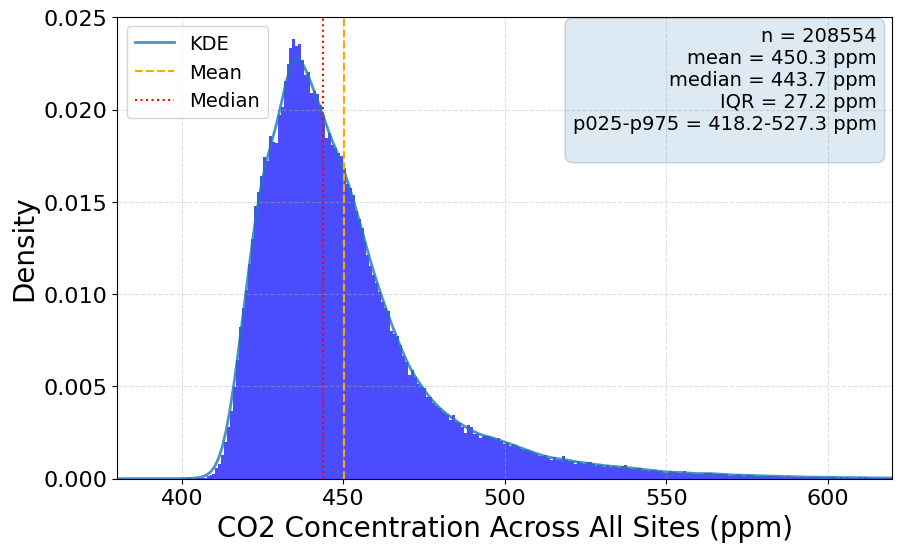

In [68]:
# calculate distribution of urban concentration measurements for all sites
show_kde = True

x = df["gmp343_corrected"].to_numpy()

fig, ax = plt.subplots(figsize=(10,6))

n = x.size

if show_kde and n > 10:
    kde = gaussian_kde(x)
    xs = np.linspace(x.min(), x.max(), 512)
    ax.plot(xs, kde(xs), linewidth=2, label='KDE', alpha=0.8)


mu = x.mean()
md = np.median(x)
ax.axvline(mu, linewidth=1.5, linestyle="--", label='Mean', color="orange")
ax.axvline(md, linewidth=1.5, linestyle=":", label='Median', color="red")

# Text box with key stats
box_text = (
    f"n = {n}\n"
    f"mean = {mu:.1f} ppm\n"
    f"median = {md:.1f} ppm\n"
    f"IQR = {np.percentile(x,75)-np.percentile(x,25):.1f} ppm\n"
    f"p025-p975 = {np.percentile(x,2.5):.1f}-{np.percentile(x,97.5):.1f} ppm\n"
)
ax.text(0.98, 0.98, box_text, transform=ax.transAxes, ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.4", alpha=0.15), fontsize=14)

# Grid and limits
ax.grid(True, linestyle="--", alpha=0.4)
ax.hist(x, bins=bins, density=True, alpha=0.7, color='blue')
ax.tick_params(axis='x', labelsize=16)  
ax.tick_params(axis='y', labelsize=16)  
ax.set_xlabel('CO2 Concentration Across All Sites (ppm)', fontsize=20)
ax.set_ylabel('Density', fontsize=20)
#ax.set_title('Distribution of Urban CO2 Concentrations Across All Sites', fontsize=18)
ax.set_xlim([380, 620])
ax.legend(fontsize=14)
plt.show()